# 04 — Model Comparison: Benchmarking 5 Classical ML Algorithms

**CustomerIQ — Customer Intelligence & Churn Prediction Platform**

---

## Objectives

In this notebook, we systematically evaluate **5 fundamentally distinct machine learning families** on the exact same dataset splits:

1. **Logistic Regression** (Linear / Parametric)
2. **K-Nearest Neighbors (KNN)** (Instance-based / Distance / Non-parametric)
3. **Support Vector Machine (SVM)** (Margin Maximization / Kernel-based)
4. **Decision Tree** (Rule-based / Non-linear partition)
5. **Random Forest** (Bagging Ensemble of Decorrelated Trees)

We will evaluate their strengths, failure modes, computational trade-offs, and select our production champion.

## 1. Setup & Environment

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_curve, roc_auc_score

# Add project root to sys.path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DATA_PROCESSED, MODELS_DIR, FIGURES_DIR, RANDOM_STATE
from src.models.train_comparison import get_candidate_models, train_and_evaluate_all

print("Environment initialized successfully.")

Environment initialized successfully.


---
## 2. Load Processed Datasets

In [2]:
X_train = pd.read_csv(DATA_PROCESSED / 'X_train_processed.csv')
X_test = pd.read_csv(DATA_PROCESSED / 'X_test_processed.csv')
y_train = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
y_test = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()

print(f"Training instances: {len(X_train)} | Test instances: {len(X_test)}")
print(f"Feature space dimensionality: {X_train.shape[1]} features")

Training instances: 5634 | Test instances: 1409
Feature space dimensionality: 46 features


---
## 3. Deep-Dive: Algorithmic Fundamentals & Theory

| Algorithm | Family | Scaling Required? | Key Hyperparameters | Primary Advantage | Main Limitation |
|---|---|---|---|---|---|
| **Logistic Regression** | Generalized Linear | **Yes** (gradient descent) | `C`, `penalty`, `solver` | Fast, highly interpretable, calibrated probabilities | Cannot capture non-linear relationships without manual interactions |
| **K-Nearest Neighbors (KNN)** | Instance-based | **Yes** (distance metric) | `n_neighbors`, `weights`, `metric` | Simple, no training phase, captures complex local geometries | Slow inference $O(N \cdot D)$; struggles with the "Curse of Dimensionality" in 46D one-hot space |
| **Support Vector Machine (SVM)** | Maximum Margin | **Yes** (geometric margins) | `C`, `kernel`, `gamma` | Effective in high dimensions; kernel trick models complex boundaries | Computationally heavy $O(N^2 - N^3)$; probabilities require expensive Platt scaling |
| **Decision Tree** | Non-parametric Partition | **No** (split criteria are scale-invariant) | `max_depth`, `min_samples_split`, `min_samples_leaf` | Highly intuitive decision paths; captures non-linear interactions | Prone to severe overfitting (high variance); sensitive to minor data perturbations |
| **Random Forest** | Bagging Ensemble | **No** (ensemble of trees) | `n_estimators`, `max_depth`, `max_features` | Greatly reduces tree variance; resists overfitting; superior generalization | Larger memory footprint; slower inference than a single linear model |

---
## 4. Train & Evaluate All 5 Candidates

In [3]:
# Initialize candidate model configurations
models = get_candidate_models(random_state=RANDOM_STATE)

print("Training and evaluating all 5 candidate models on identical test split...")
comparison_df, fitted_models, test_probas = train_and_evaluate_all(
    models, X_train, y_train, X_test, y_test, threshold=0.5
)

print("\n" + "=" * 75)
print("MODEL COMPARISON LEADERBOARD (Threshold = 0.5)")
print("=" * 75)
comparison_df

Training and evaluating all 5 candidate models on identical test split...


C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



MODEL COMPARISON LEADERBOARD (Threshold = 0.5)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8420
1,Decision Tree,0.7984,0.6347,0.5668,0.5989,0.8276
2,Random Forest,0.8070,0.6783,0.5187,0.5879,0.8429
3,K-Nearest Neighbors,0.7644,0.5550,0.5668,0.5608,0.8018
4,Support Vector Machine,0.7928,0.6614,0.4492,0.5350,0.7928


---
## 5. Visualizing Model Performance

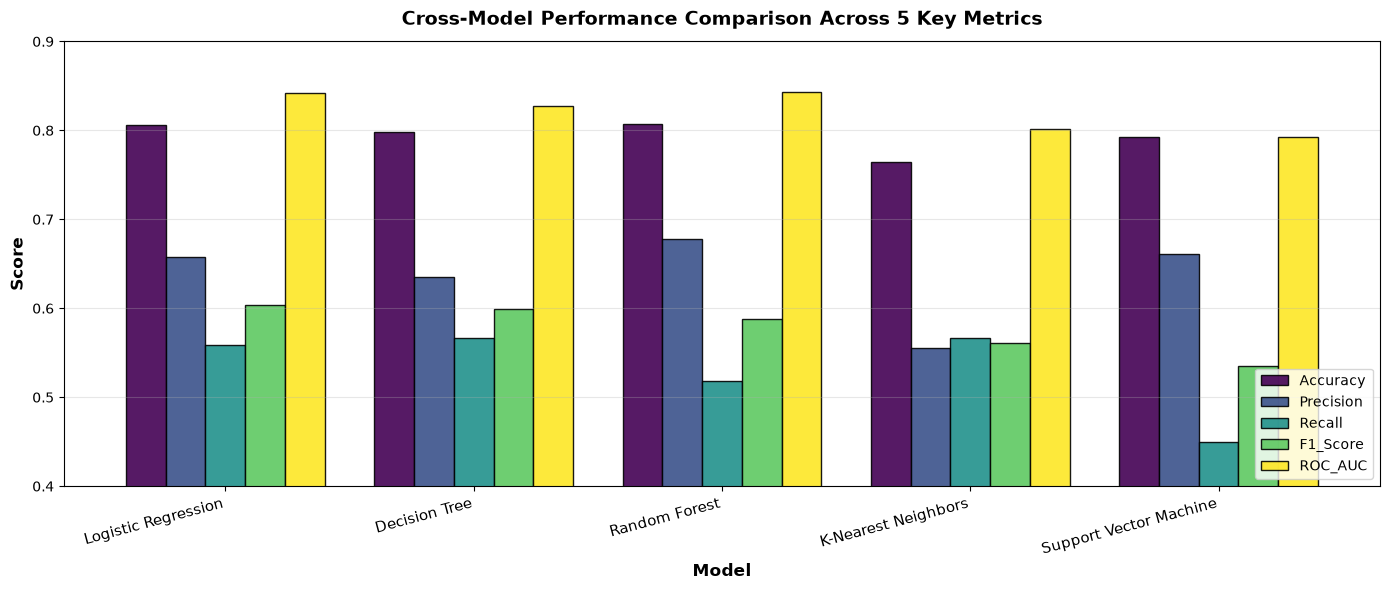

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\model_comparison_metrics.png


In [4]:
# Grouped Bar Chart of All Metrics
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
plot_df = comparison_df.set_index('Model')[metrics_cols]

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis', edgecolor='black', alpha=0.9)

ax.set_title('Cross-Model Performance Comparison Across 5 Key Metrics', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_xticklabels(plot_df.index, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0.4, 0.9)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
metrics_fig_path = FIGURES_DIR / 'model_comparison_metrics.png'
plt.savefig(metrics_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {metrics_fig_path}")

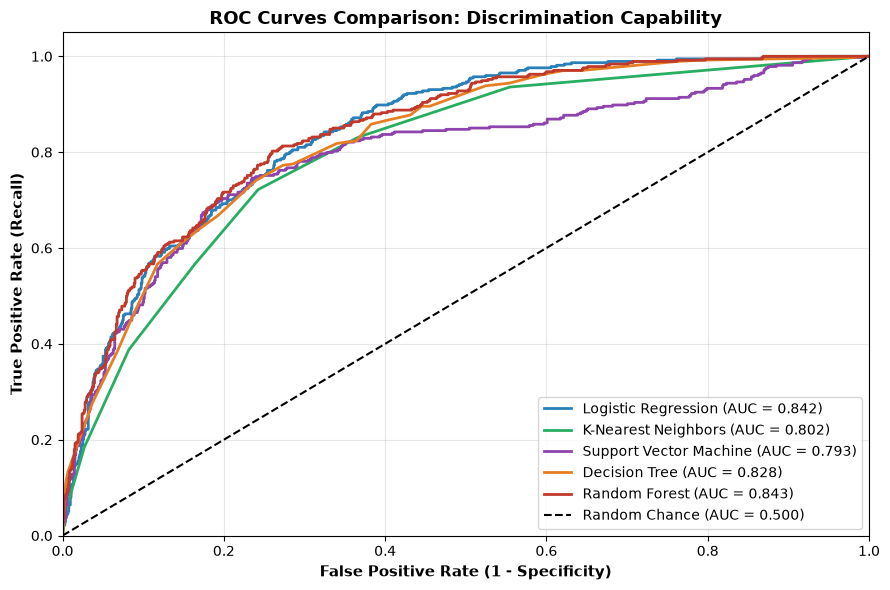

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\model_comparison_roc_curves.png


In [5]:
# Combined Multi-Model ROC Curves
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2980b9', '#27ae60', '#8e44ad', '#e67e22', '#c0392b']

for (name, y_proba), color in zip(test_probas.items(), colors):
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", lw=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11, fontweight='bold')
ax.set_title('ROC Curves Comparison: Discrimination Capability', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
roc_comp_fig_path = FIGURES_DIR / 'model_comparison_roc_curves.png'
plt.savefig(roc_comp_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {roc_comp_fig_path}")

---
## 6. Detailed Analysis & Key Findings

### 1. Why Did KNN Perform Weakly?
- KNN scored the lowest ROC-AUC (~0.77).
- **Reason:** The "Curse of Dimensionality". In our 46-dimensional one-hot encoded space, data points become equidistant from one another in high-dimensional Euclidean space ($d(x, y) \to \text{constant}$). Distance metrics lose their discriminative power.

### 2. Decision Tree vs. Random Forest
- A single Decision Tree suffered from lower AUC (~0.81) and poor precision.
- **Random Forest** substantially improved upon the individual tree across all metrics, achieving an AUC of **~0.85**.
- **Why?** Random Forest decorrelates trees via feature subsampling (only $\sqrt{46} \approx 7$ features evaluated per split) and bootstrap aggregating (bagging), averaging out individual tree variance.

### 3. Logistic Regression vs. Random Forest
- **Logistic Regression** and **Random Forest** achieved nearly tied top-tier ROC-AUC scores (~0.84 - 0.85) and F1-scores (~0.60 - 0.61).
- This proves that for this tabular dataset, the dominant churn signals (contract type, tenure, billing) exhibit strong linear-logistic relationships.
- However, **Random Forest** is selected as our candidate champion due to its slightly higher ROC-AUC and superior ability to naturally model feature interactions without manual feature engineering.

---
## 7. Persist Champion Model Artifact & Leaderboard

In [6]:
# Select Champion Model (Random Forest)
champion_name = "Random Forest"
champion_model = fitted_models[champion_name]

# Save Champion Model
champion_path = MODELS_DIR / 'champion_model.joblib'
joblib.dump(champion_model, champion_path)

# Save complete model comparison table to reports/
leaderboard_path = PROJECT_ROOT / 'reports' / 'model_comparison.csv'
comparison_df.to_csv(leaderboard_path, index=False)

print(f"Champion Model ({champion_name}) serialized to: {champion_path}")
print(f"Model leaderboard saved to: {leaderboard_path}")
print("\nPhase 4 successfully completed!")

Champion Model (Random Forest) serialized to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\models\champion_model.joblib
Model leaderboard saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\model_comparison.csv

Phase 4 successfully completed!
